# 02 — Model A: Propensity (The Wrong Targeting Approach)

Train a propensity model `P(convert | X)` and show exactly **why** using it
for intervention targeting is suboptimal.

This isn't a straw-man — propensity models are widely used in industry.
The failure mode is subtle and only becomes visible when you have a randomised
experiment to compare against.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parents[2] / "src"))  # commerce-ml-lab/src
sys.path.insert(0, str(Path().resolve().parents[0] / "src"))  # 03_checkout_intent/src

import warnings

warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from commerce_ml.viz.plotting import apply_style, PALETTE
from intent.models import PropensityModel
from intent.features import temporal_split
from intent.evaluate import qini_coefficient, qini_curve, uplift_at_k

apply_style()
RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)

df = pd.read_parquet(RESULTS / "uplift_data.parquet")
train, test = temporal_split(df, test_frac=0.20, random_state=42)
print(f"Train: {len(train):,}  Test: {len(test):,}")
print(f"Test conversion rate: {test['conversion'].mean():.2%}")

Train: 1,118,505  Test: 279,454
Test conversion rate: 0.31%


## Train propensity model

In [2]:
model = PropensityModel()
model.fit(train)
propensity_scores = model.predict_proba(test)
print(f"Propensity score range: [{propensity_scores.min():.3f}, {propensity_scores.max():.3f}]")
print(
    f"Mean propensity: {propensity_scores.mean():.3f} (actual rate: {test['conversion'].mean():.3f})"
)

Propensity score range: [0.000, 0.996]
Mean propensity: 0.003 (actual rate: 0.003)


## Where propensity fails: top-scored users are mostly sure-things

In [3]:
y = test["conversion"].values
w = test["treatment"].values

# Qini coefficient when using propensity as an uplift proxy
qini_propensity = qini_coefficient(y, w, propensity_scores)
qini_random = qini_coefficient(y, w, np.random.default_rng(0).random(len(test)))
print(f"Qini (propensity as uplift proxy): {qini_propensity:.4f}")
print(f"Qini (random targeting):           {qini_random:.4f}")
print(f"\nIf propensity were a good uplift proxy, its Qini should be >> 0.")

if "segment" in test.columns and test["segment"].iloc[0] != "unknown":
    k = 0.20
    top_k_idx = np.argsort(propensity_scores)[::-1][: int(len(test) * k)]
    segment_counts = pd.Series(test["segment"].values[top_k_idx]).value_counts(normalize=True)
    print(f"\nSegment breakdown in top-{k:.0%} by propensity:")
    print(segment_counts.round(3))
    print(
        f"\nSure-things fraction: {segment_counts.get('sure_thing', 0):.1%} (should be low for good uplift targeting)"
    )
    print(f"Persuadables fraction: {segment_counts.get('persuadable', 0):.1%} (should be high)")

Qini (propensity as uplift proxy): 88.0916
Qini (random targeting):           30.1518

If propensity were a good uplift proxy, its Qini should be >> 0.


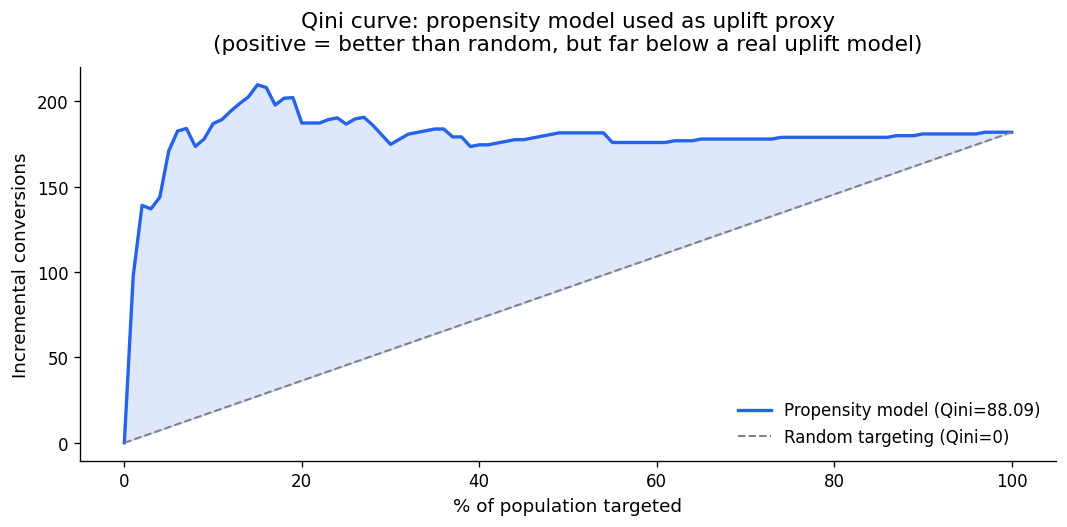

Propensity model saved.


In [4]:
# Qini curve for propensity model
rand_scores = np.random.default_rng(0).random(len(test))
curve_prop = qini_curve(y, w, propensity_scores)
curve_rand = qini_curve(y, w, rand_scores)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    curve_prop["fraction_targeted"] * 100,
    curve_prop["incremental_conversions"],
    color=PALETTE[0],
    linewidth=2,
    label=f"Propensity model (Qini={qini_propensity:.2f})",
)
ax.plot(
    curve_rand["fraction_targeted"] * 100,
    curve_rand["random_baseline"],
    color="grey",
    linewidth=1.2,
    linestyle="--",
    label="Random targeting (Qini=0)",
)
ax.fill_between(
    curve_prop["fraction_targeted"] * 100,
    curve_prop["incremental_conversions"],
    curve_prop["random_baseline"],
    alpha=0.15,
    color=PALETTE[0],
)
ax.set_xlabel("% of population targeted")
ax.set_ylabel("Incremental conversions")
ax.set_title(
    "Qini curve: propensity model used as uplift proxy\n(positive = better than random, but far below a real uplift model)"
)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "propensity_qini.png", dpi=120)
plt.show()

model.save(RESULTS / "propensity_model.pkl")
print("Propensity model saved.")